# Heart Disease Prediction
## Comparative Analysis of SVM, Naive Bayes and Decision Tree

**Dataset:** Heart Disease Cleveland Dataset

**Algorithms:**
1. Support Vector Machine (SVM)
2. Gaussian Naive Bayes
3. Decision Tree

**Preprocessing:** Missing-value check, categorical feature identification, One-Hot Encoding, train-test split and feature scaling.

**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix and ROC Curve.

In [2]:
# Install if required
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load Dataset

In [3]:
# Use the uploaded CSV file
file_path = "Heart_disease_cleveland_new.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## 2. Basic Data Processing and Inspection

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe())

Dataset shape: (303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Duplicate rows: 0

Statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [5]:
# Remove duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (303, 14)


## 3. Target/Class Distribution

In [6]:
print(df["target"].value_counts())
print("\nTarget percentages:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

target
0    164
1    139
Name: count, dtype: int64

Target percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


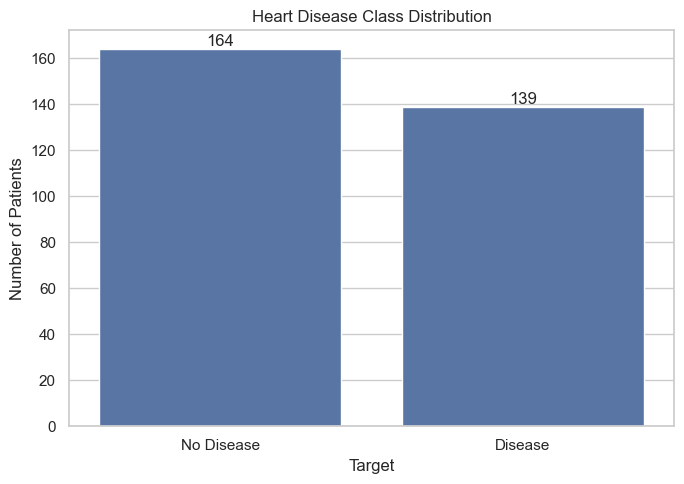

In [7]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x="target", data=df)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 4. Separate Features and Target

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (303, 13)
Target shape: (303,)


## 5. Identify Categorical and Numerical Features

In [9]:
# These variables are categorical in the Cleveland dataset
categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

# Continuous/numerical variables
numerical_features = [
    "age", "trestbps", "chol",
    "thalach", "oldpeak"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


## 6. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


## 7. One-Hot Encoding and Feature Scaling

In [11]:
# OneHotEncoder converts categorical variables into binary columns.
# StandardScaler standardizes numerical variables.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print("Categorical features will be One-Hot Encoded.")
print("Numerical features will be Standardized.")

Preprocessing pipeline created.
Categorical features will be One-Hot Encoded.
Numerical features will be Standardized.


## 8. View Processed Data

In [12]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

print("Processed training shape:", X_train_processed_df.shape)
display(X_train_processed_df.head())

Processed training shape: (242, 28)


,categorical__sex_0,categorical__sex_1,categorical__cp_0,categorical__cp_1,categorical__cp_2,categorical__cp_3,categorical__fbs_0,categorical__fbs_1,categorical__restecg_0,categorical__restecg_1,...,categorical__ca_2,categorical__ca_3,categorical__thal_1,categorical__thal_2,categorical__thal_3,numerical__age,numerical__trestbps,numerical__chol,numerical__thalach,numerical__oldpeak
180,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.729485,-0.395692,0.458139,0.708371,-0.445445
208,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.050166,-0.054513,0.230598,0.222495,-0.891627
167,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,-0.061212,0.059213,0.723605,0.399178,-0.891627
105,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.061212,-1.305501,1.121803,0.266666,-0.891627
297,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.272924,0.514117,-0.167601,-1.190962,-0.713154


## 9. SVM

In [13]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

y_pred_svm = svm_model.predict(X_test_processed)
y_prob_svm = svm_model.predict_proba(X_test_processed)[:, 1]

print("SVM training completed.")

SVM training completed.


In [14]:
svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
}

display(pd.DataFrame([svm_metrics], index=["SVM"]).round(4))

print("\nSVM Classification Report:")
print(classification_report(
    y_test, y_pred_svm,
    target_names=["No Disease", "Disease"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM,0.8852,0.8387,0.9286,0.8814,0.9643



SVM Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



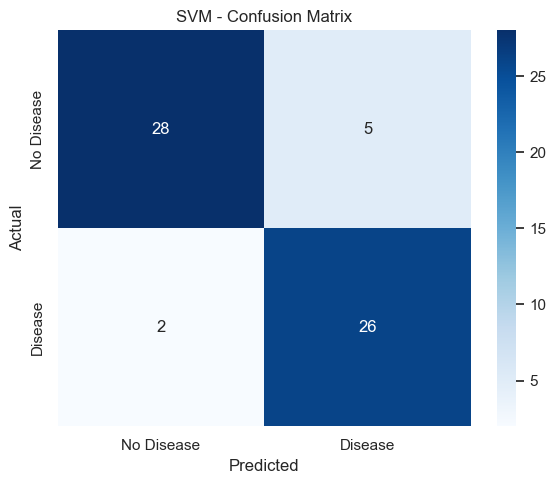

In [15]:
# SVM Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

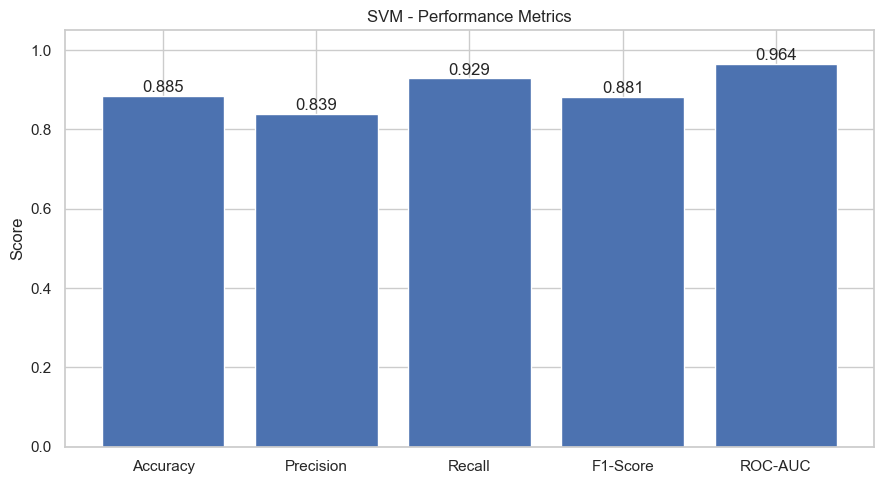

In [16]:
# SVM Graph 2: Performance Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
values = [svm_metrics[m] for m in metrics]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, values)
plt.title("SVM - Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

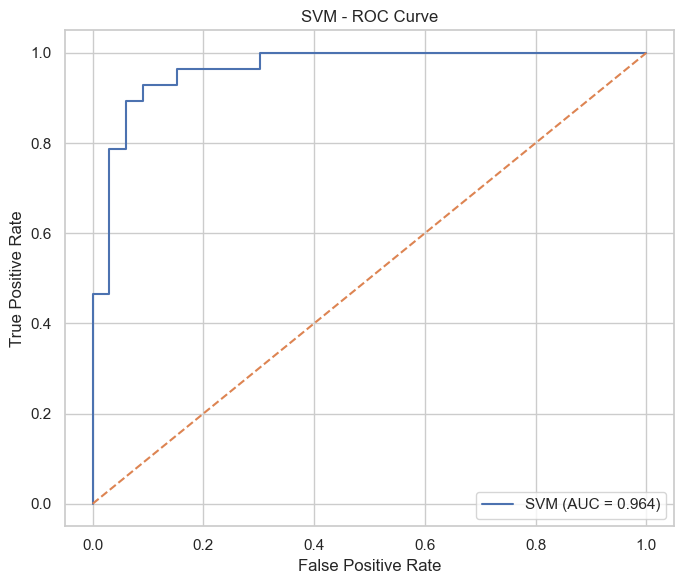

In [17]:
# SVM Graph 3: ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_svm, tpr_svm,
    label=f"SVM (AUC = {svm_metrics['ROC-AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("SVM - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Naive Bayes

In [18]:
nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train)

y_pred_nb = nb_model.predict(X_test_processed)
y_prob_nb = nb_model.predict_proba(X_test_processed)[:, 1]

print("Naive Bayes training completed.")

Naive Bayes training completed.


In [19]:
nb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_nb, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_nb, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nb)
}

display(pd.DataFrame([nb_metrics], index=["Naive Bayes"]).round(4))

print("\nNaive Bayes Classification Report:")
print(classification_report(
    y_test, y_pred_nb,
    target_names=["No Disease", "Disease"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Naive Bayes,0.7213,0.641,0.8929,0.7463,0.8268



Naive Bayes Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.58      0.69        33
     Disease       0.64      0.89      0.75        28

    accuracy                           0.72        61
   macro avg       0.75      0.73      0.72        61
weighted avg       0.76      0.72      0.72        61



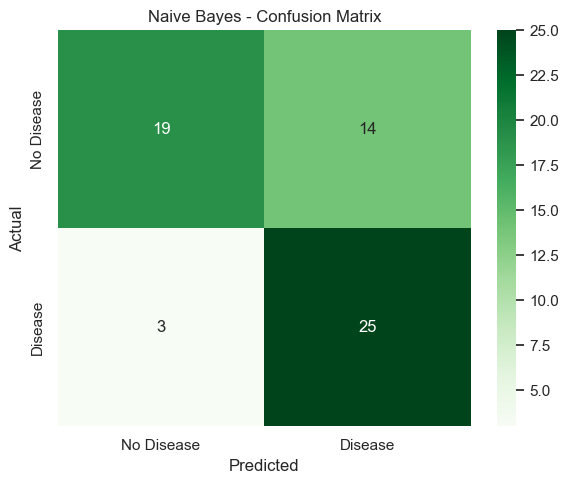

In [20]:
# Naive Bayes Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

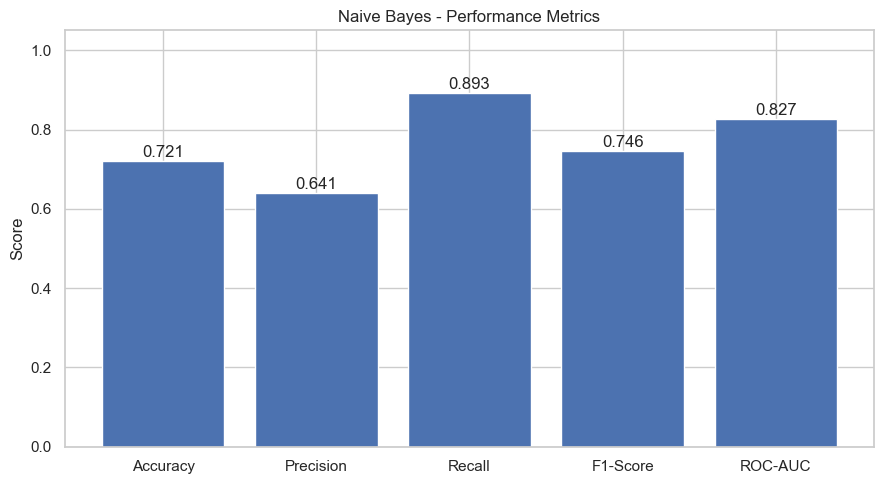

In [21]:
# Naive Bayes Graph 2: Performance Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
values = [nb_metrics[m] for m in metrics]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, values)
plt.title("Naive Bayes - Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

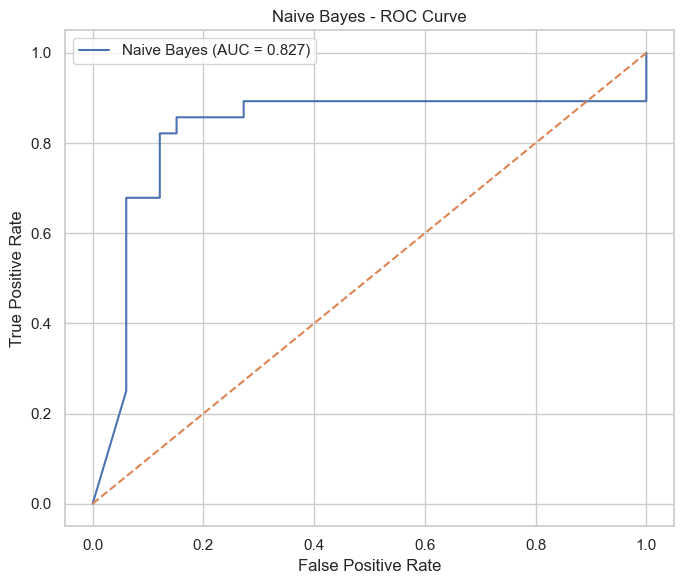

In [22]:
# Naive Bayes Graph 3: ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_nb, tpr_nb,
    label=f"Naive Bayes (AUC = {nb_metrics['ROC-AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Naive Bayes - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Decision Tree

In [23]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree training completed.")

Decision Tree training completed.


In [24]:
dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dt, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_dt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

display(pd.DataFrame([dt_metrics], index=["Decision Tree"]).round(4))

print("\nDecision Tree Classification Report:")
print(classification_report(
    y_test, y_pred_dt,
    target_names=["No Disease", "Disease"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.7377,0.7,0.75,0.7241,0.789



Decision Tree Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.73      0.75        33
     Disease       0.70      0.75      0.72        28

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



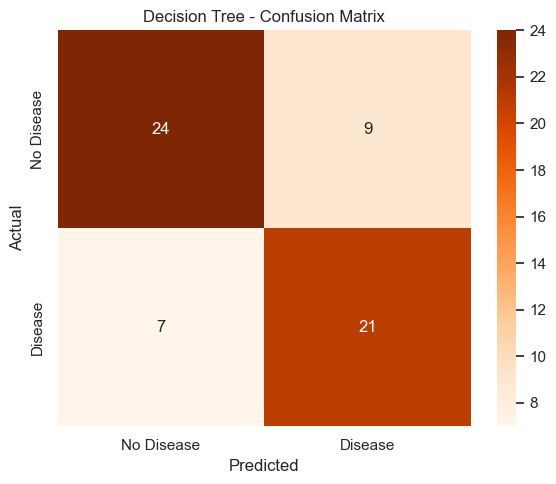

In [25]:
# Decision Tree Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

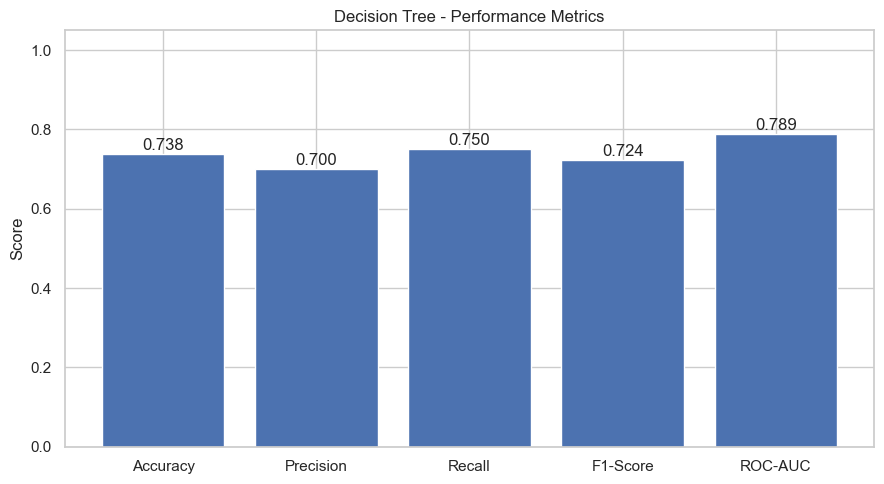

In [26]:
# Decision Tree Graph 2: Performance Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
values = [dt_metrics[m] for m in metrics]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, values)
plt.title("Decision Tree - Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

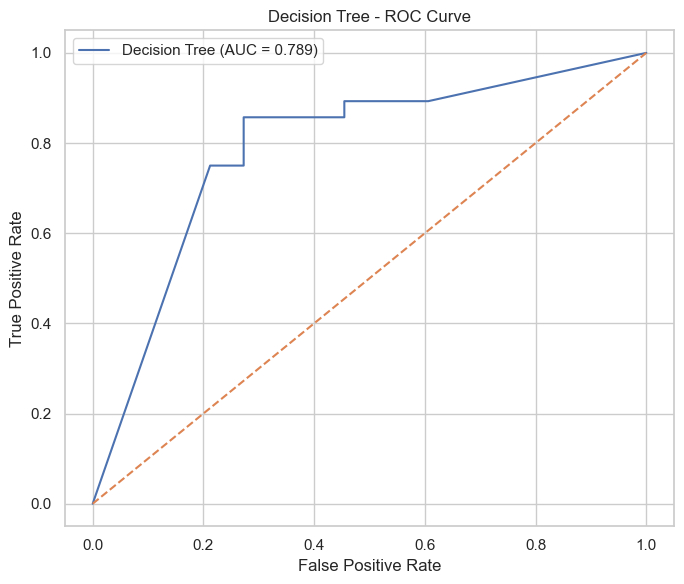

In [27]:
# Decision Tree Graph 3: ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC = {dt_metrics['ROC-AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Decision Tree - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Final Comparison

In [28]:
results_df = pd.DataFrame(
    [svm_metrics, nb_metrics, dt_metrics],
    index=["SVM", "Naive Bayes", "Decision Tree"]
)

print("Final Model Comparison:")
display(results_df.round(4))

Final Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM,0.8852,0.8387,0.9286,0.8814,0.9643
Naive Bayes,0.7213,0.6410,0.8929,0.7463,0.8268
Decision Tree,0.7377,0.7000,0.7500,0.7241,0.7890


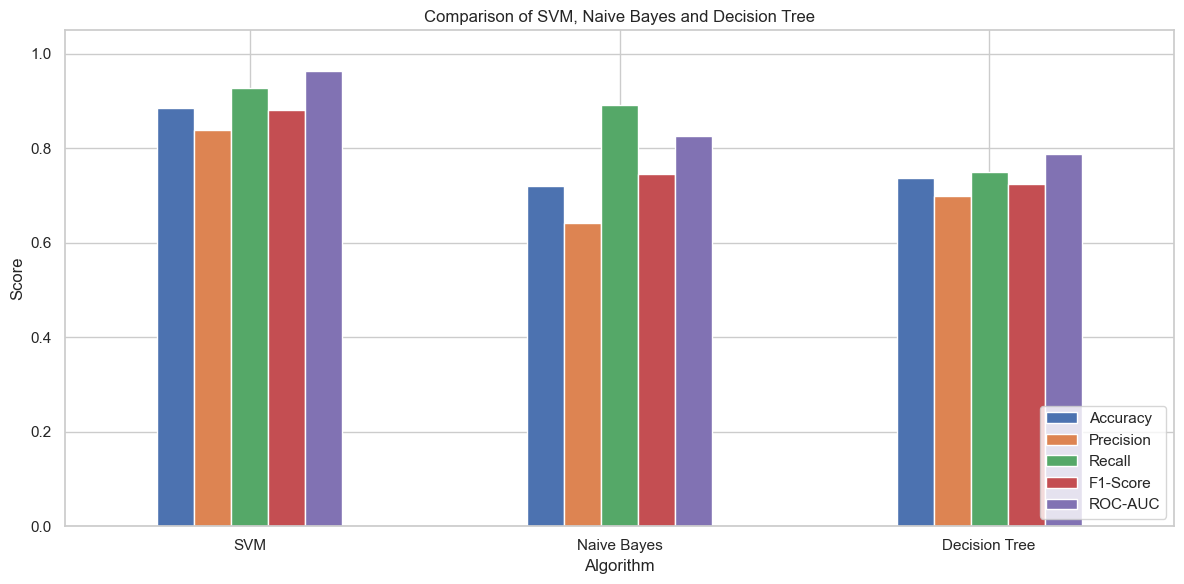

In [29]:
# Final comparison graph
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

ax = results_df[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of SVM, Naive Bayes and Decision Tree")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

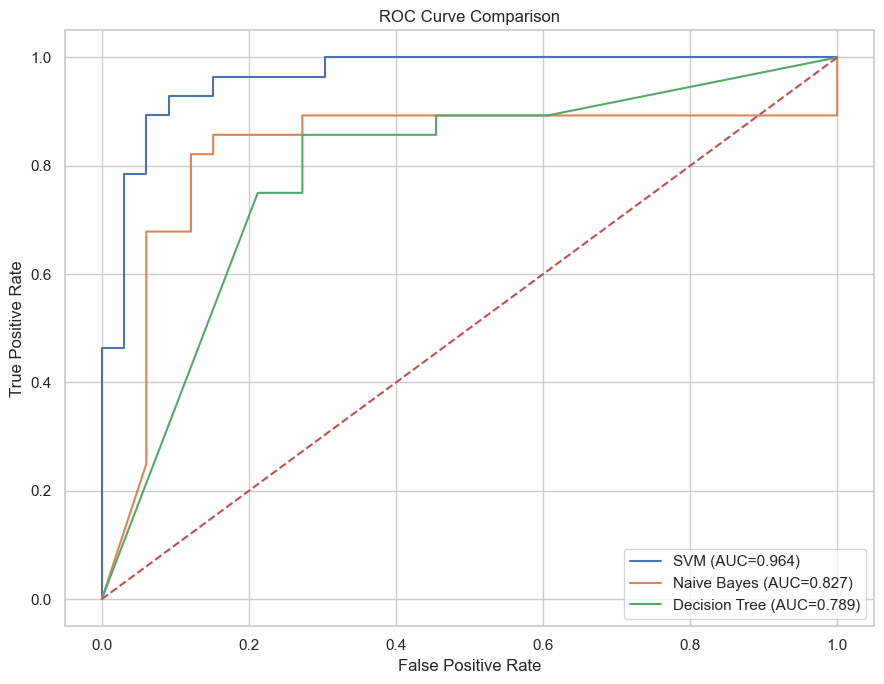

In [30]:
# Combined ROC Curve Comparison
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_svm, tpr_svm,
    label=f"SVM (AUC={svm_metrics['ROC-AUC']:.3f})"
)
plt.plot(
    fpr_nb, tpr_nb,
    label=f"Naive Bayes (AUC={nb_metrics['ROC-AUC']:.3f})"
)
plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC={dt_metrics['ROC-AUC']:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Best Model

In [31]:
best_accuracy = results_df["Accuracy"].idxmax()
best_f1 = results_df["F1-Score"].idxmax()
best_auc = results_df["ROC-AUC"].idxmax()

print("Best model by Accuracy:", best_accuracy)
print("Best model by F1-Score:", best_f1)
print("Best model by ROC-AUC:", best_auc)

Best model by Accuracy: SVM
Best model by F1-Score: SVM
Best model by ROC-AUC: SVM
